In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

LOADING THE DATASET

In [76]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00254/biodeg.csv"

data = pd.read_csv(url, sep=';', header=None)
print("Dataset Shape:", X.shape)

Dataset Shape: (1055, 41)


FEATURING THE DATA

K-Means is an unsupervised learning algorithm and does not use target labels during training. It forms clusters solely based on the similarity of the feature values. Since the class labels (RB and NRB) are not used in the clustering process, there is no need to encode them.

In [86]:
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

#Encoding the labels is not required for K-Means Clustering.

SCALING THE DATASET

In [78]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

ELBOW METHOD

The Elbow Method is used to determine the optimal number of clusters for K-Means clustering. It evaluates the Within-Cluster Sum of Squares (WCSS) for different values of K. 
As the number of clusters increases, WCSS decreases because data points become closer to their respective centroids. 
The optimal number of clusters is chosen at the point where the decrease in WCSS begins to slow significantly, forming an "elbow" in the graph. This provides a balance between compact clusters and avoiding unnecessary complexity.

In [79]:
wcss = []

for k in range(1,11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

ELBOW PLOT

The Elbow Plot signifies how the clustering quality changes as you increase the number of clusters (K).


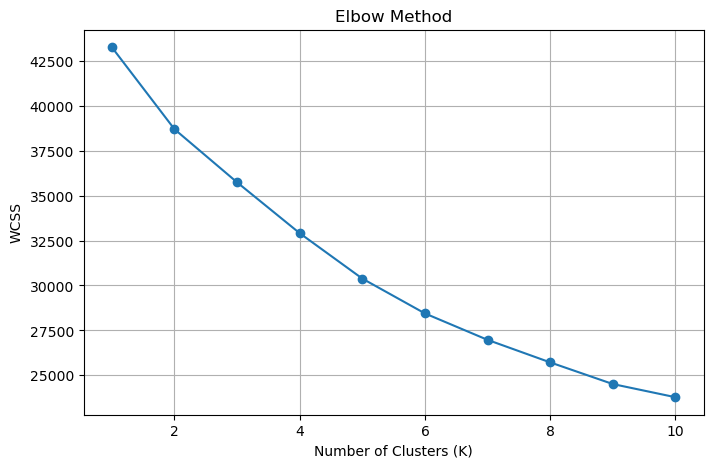

In [80]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

TRAINING FINAL MODEL

In [81]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

PCA FOR VISUALIZATION

PCA is needed as the QSAR dataset has many features (descriptors), and we cannot visualize data in such a high-dimensional space. PCA reduces the data to two dimensions while preserving as much information as possible, allowing us to create a 2D scatter plot.

In [82]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

SCATTER PLOT

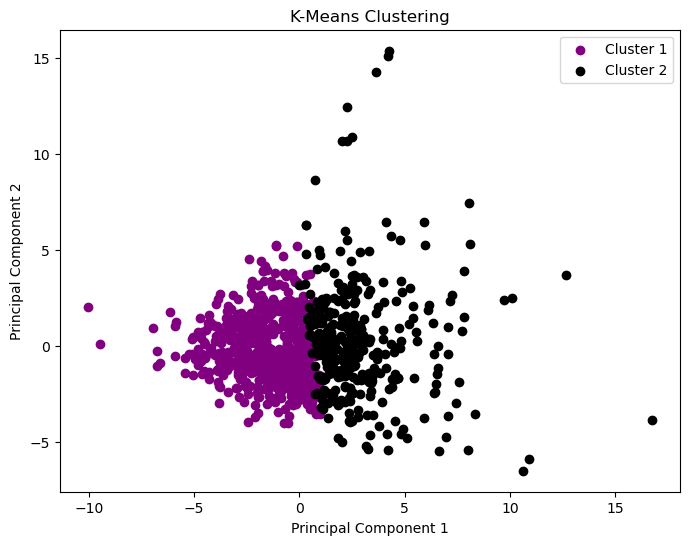

In [83]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[clusters == 0, 0],
    X_pca[clusters == 0, 1],
    color='purple',
    label='Cluster 1'
)

plt.scatter(
    X_pca[clusters == 1, 0],
    X_pca[clusters == 1, 1],
    color='black',
    label='Cluster 2'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering")
plt.legend()

plt.show()




SCATTER PLOT WITH CENTROIDS

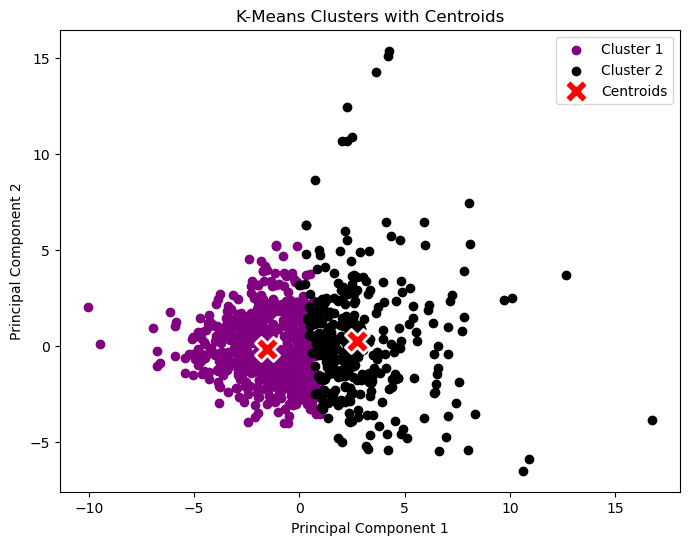

In [84]:
# Transform the two centroids into PCA space
centers = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8,6))

# Cluster 1
plt.scatter(
    X_pca[clusters == 0, 0],
    X_pca[clusters == 0, 1],
    color='purple',
    label='Cluster 1'
)

# Cluster 2
plt.scatter(
    X_pca[clusters == 1, 0],
    X_pca[clusters == 1, 1],
    color='black',
    label='Cluster 2'
)

# Plot only the two centroids
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker='X',
    s=300,
    color='red',
    edgecolor='white',
    linewidth=2,
    label='Centroids'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters with Centroids")
plt.legend()

plt.show()

SILHOUETTE SCORE

In [85]:
score = silhouette_score(
    X_scaled,
    clusters
)

print("Silhouette Score:", score)

Silhouette Score: 0.1918818309859869


In [ ]:
#references: https://www.kaggle.com/code/satishgunjal/tutorial-k-means-clustering/input